# 🥗 Nutrition Recommendation System
### Unsupervised Machine Learning | KMeans Clustering

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully ✓")

Libraries imported successfully ✓


## 2. Configuration

In [5]:
# ── Update this path to your CSV file ──
DATA_PATH = r"C:\Users\Lenovo\Desktop\Data Science Training\ML\unsupervised_ML\project\Nutrition recommendation system\Data\Food_Nutrition_Dataset.csv"

N_CLUSTERS   = 4
RANDOM_STATE = 42

# Descriptive names for each cluster (update after inspecting cluster means)
CLUSTER_LABELS = {
    0: "High-Calorie Dense Foods",
    1: "Vitamin-Rich Foods",
    2: "High-Protein Dense Foods",
    3: "Balanced Light Foods",
}

CLUSTER_COLORS = {0: "#E53935", 1: "#43A047", 2: "#1E88E5", 3: "#FB8C00"}

FEATURES = ["calories", "protein", "carbs", "fat", "iron", "vitamin_c"]

ENGINEERED_FEATURES = FEATURES + [
    "protein_per_cal", "carb_per_cal", "fat_per_cal", "micronutrient_score"
]

## 3. Load & Clean Data

In [6]:
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\Data Science Training\ML\unsupervised_ML\project\Nutrition recommendation system\Data\Food_Nutrition_Dataset.csv")

print(f"Shape      : {df.shape}")
print(f"Columns    : {df.columns.tolist()}")
print(f"Categories : {df['category'].nunique()} unique")

df.head()

Shape      : (205, 8)
Columns    : ['food_name', 'category', 'calories', 'protein', 'carbs', 'fat', 'iron', 'vitamin_c']
Categories : 61 unique


,food_name,category,calories,protein,carbs,fat,iron,vitamin_c
0,"Apple, candied",Apples,134.0,1.34,29.61,2.15,0.12,3.6
1,"Apple, raw",Apples,61.0,0.17,14.80,0.15,0.03,4.6
2,"Apple, dried",Dried fruits,243.0,0.93,65.89,0.32,1.40,3.9
3,"Crisp, apple",Cakes and pies,215.0,2.81,30.18,9.59,1.00,0.6
4,"Apple, baked",Apples,113.0,0.32,22.70,3.08,0.19,3.9


In [7]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
food_name    0
category     0
calories     0
protein      0
carbs        0
fat          0
iron         2
vitamin_c    3
dtype: int64


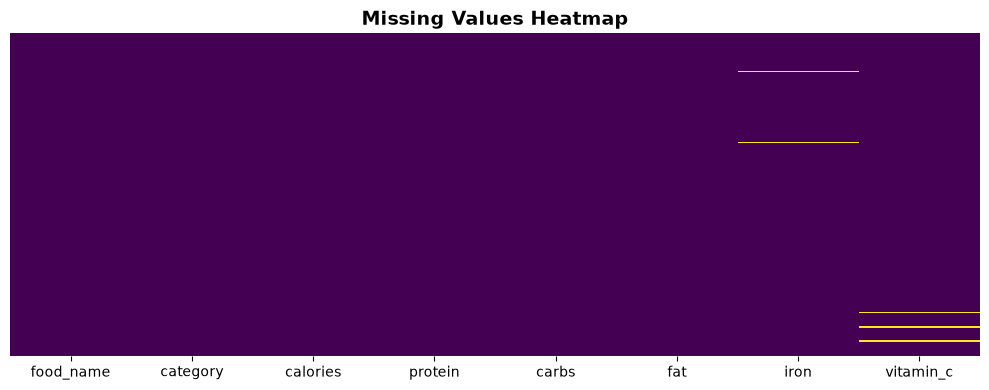

In [8]:
# Missing value heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Values Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# Fill missing numerical values with median (robust to outliers)
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Missing values after fill:", df.isnull().sum().sum())
print("Dataset clean ✓")

Removed 0 duplicate rows
Missing values after fill: 0
Dataset clean ✓


## 4. Exploratory Data Analysis

In [10]:
df.describe().round(2)

,calories,protein,carbs,fat,iron,vitamin_c
count,205.00,205.00,205.00,205.00,205.00,205.00
mean,243.79,2.85,25.57,6.02,0.85,13.60
std,283.58,3.36,20.12,9.69,1.10,18.38
min,16.00,0.00,1.79,0.00,0.00,0.00
25%,62.00,0.64,11.20,0.20,0.21,1.70
50%,166.00,1.71,17.22,1.18,0.41,7.45
75%,296.00,3.20,37.55,9.39,1.06,16.70
max,1460.00,17.80,85.13,74.02,9.09,136.00


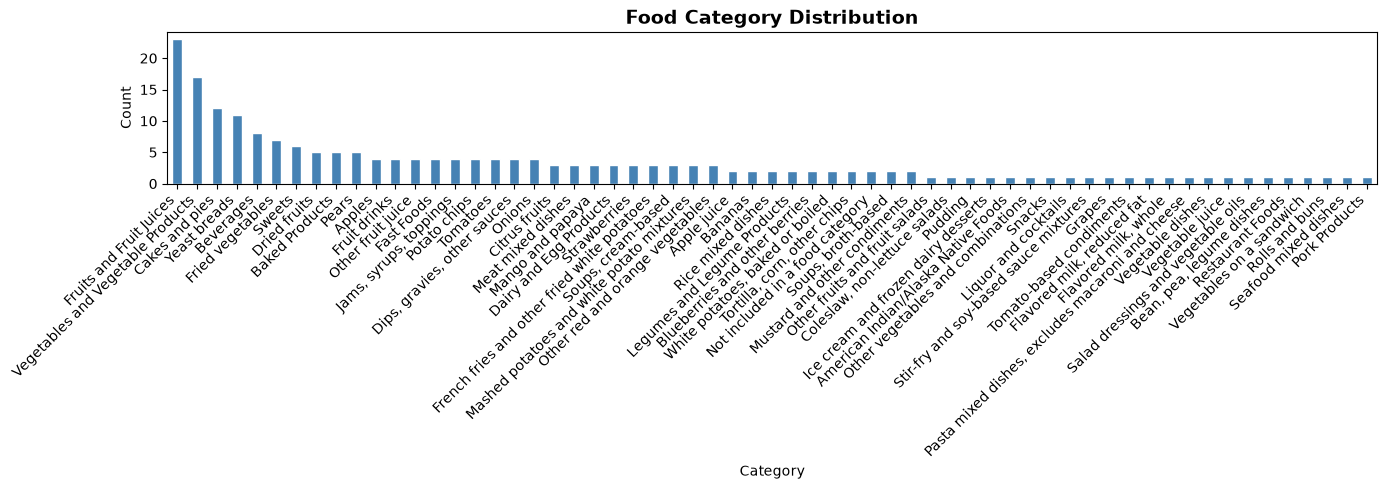

In [11]:
# Category distribution
plt.figure(figsize=(14, 5))
df["category"].value_counts().plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Food Category Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

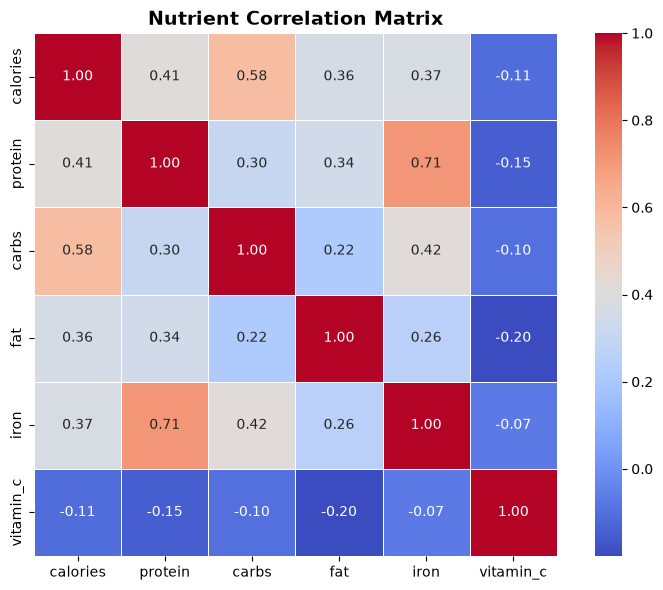

In [12]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Nutrient Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

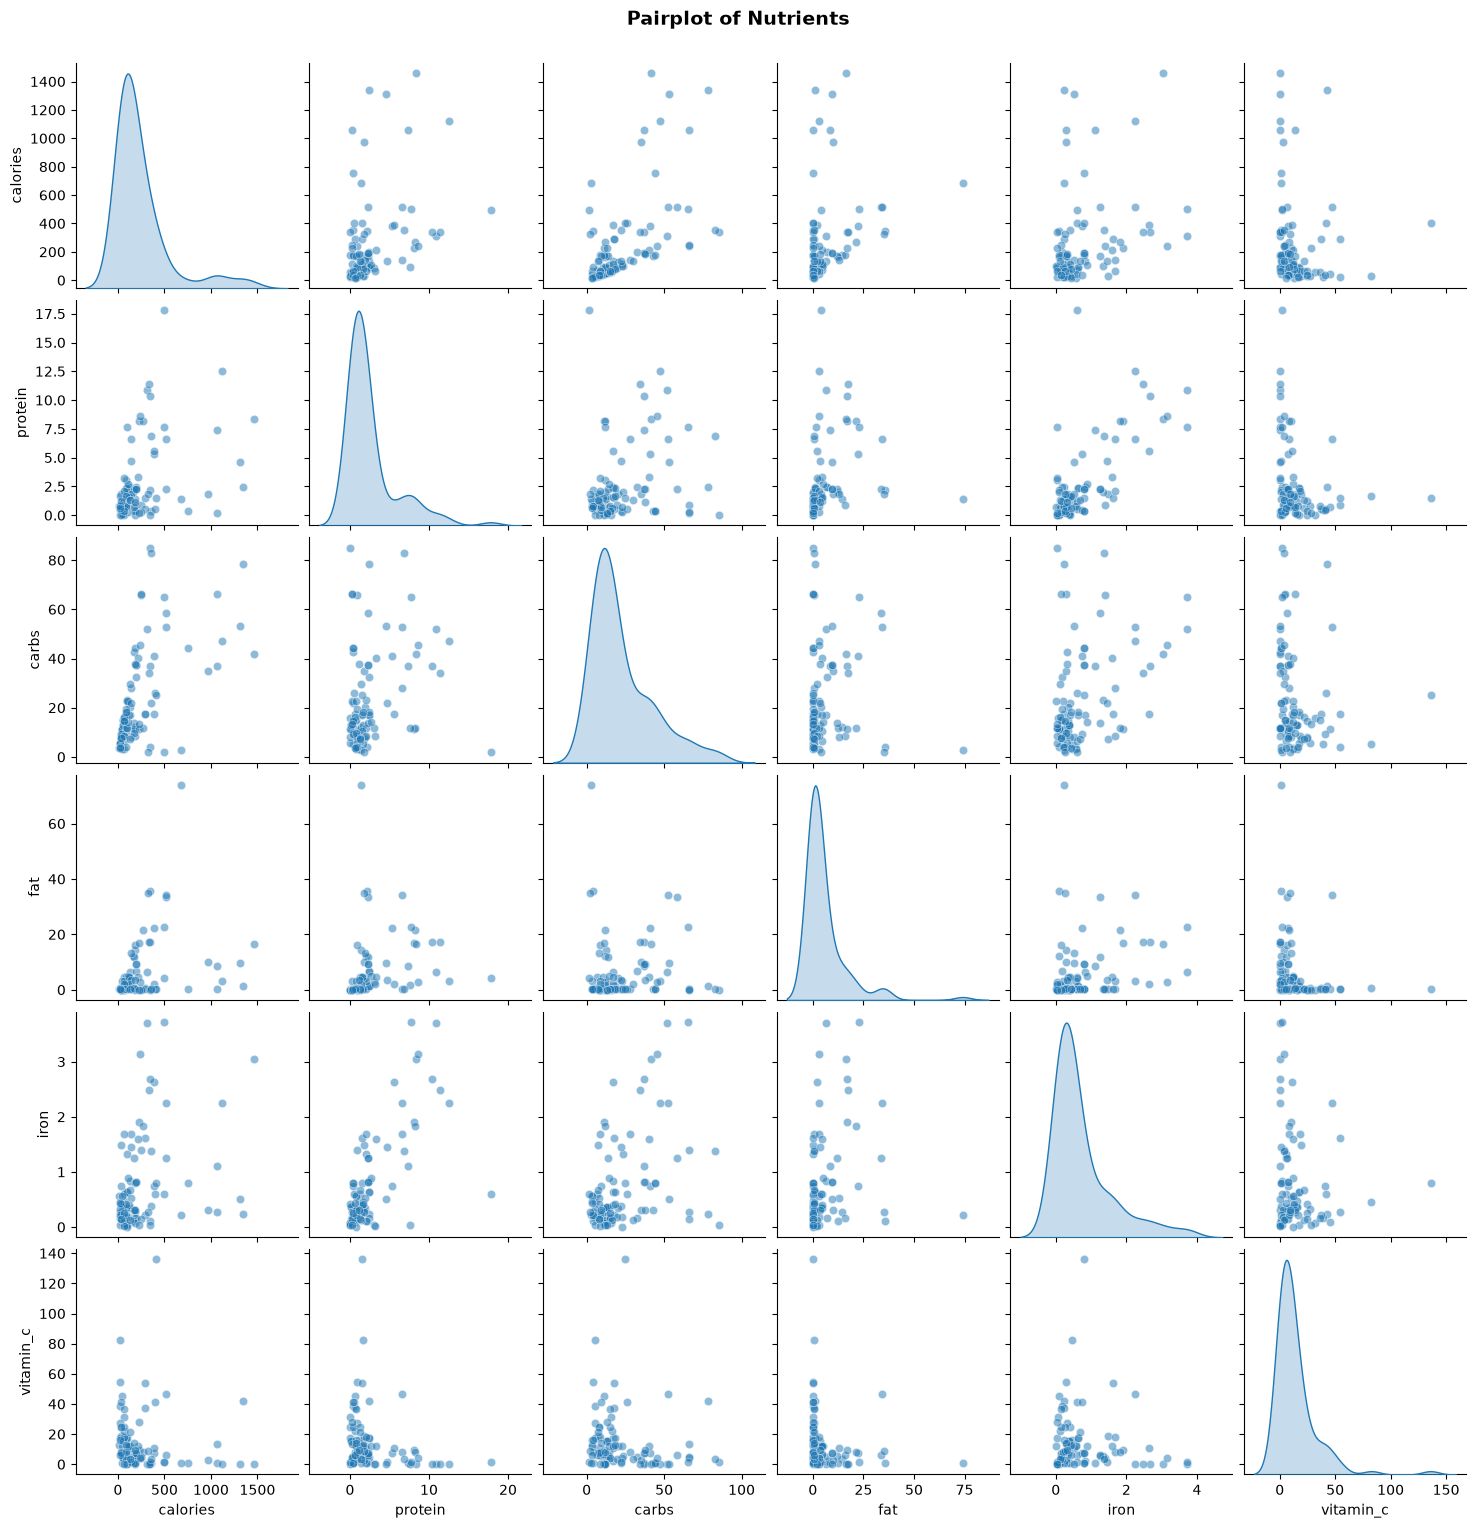

In [13]:
# Pairplot of key nutrients
sns.pairplot(df[FEATURES + ["category"]].sample(min(100, len(df))),
             diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot of Nutrients", y=1.02, fontsize=14, fontweight="bold")
plt.show()

## 5. Feature Engineering

In [14]:
# Add nutritional ratio features that improve cluster separation
df["protein_per_cal"]     = df["protein"]  / (df["calories"] + 1)
df["carb_per_cal"]        = df["carbs"]    / (df["calories"] + 1)
df["fat_per_cal"]         = df["fat"]      / (df["calories"] + 1)
df["micronutrient_score"] = df["iron"] * 2 + df["vitamin_c"] * 0.1

print("Engineered features added:")
print(df[ENGINEERED_FEATURES].describe().round(3))

Engineered features added:
       calories  protein    carbs      fat     iron  vitamin_c  \
count    205.00  205.000  205.000  205.000  205.000    205.000   
mean     243.79    2.853   25.573    6.018    0.847     13.603   
std      283.58    3.357   20.119    9.695    1.099     18.382   
min       16.00    0.000    1.790    0.000    0.000      0.000   
25%       62.00    0.640   11.200    0.200    0.210      1.700   
50%      166.00    1.710   17.220    1.180    0.410      7.450   
75%      296.00    3.200   37.550    9.390    1.060     16.700   
max     1460.00   17.800   85.130   74.020    9.090    136.000   

       protein_per_cal  carb_per_cal  fat_per_cal  micronutrient_score  
count          205.000       205.000      205.000              205.000  
mean             0.016         0.152        0.023                3.054  
std              0.017         0.077        0.026                2.766  
min              0.000         0.004        0.000                0.050  
25%          

## 6. Feature Scaling
>  is used instead of  because it handles outliers better — useful when one food (e.g. 1460-cal bread) would skew the scale.

In [15]:
X = df[ENGINEERED_FEATURES].values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled shape : {X_scaled.shape}")
print("RobustScaler applied ✓")

Scaled shape : (205, 10)
RobustScaler applied ✓


## 7. Find Optimal Number of Clusters
### 7.1 Elbow Method

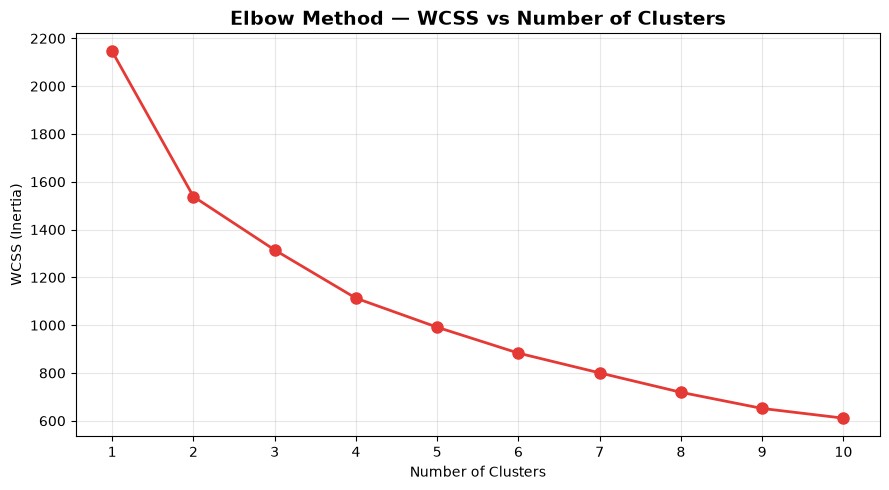

In [16]:
wcss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker="o", color="#E53935", linewidth=2, markersize=8)
plt.title("Elbow Method — WCSS vs Number of Clusters", fontsize=14, fontweight="bold")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Inertia)")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Silhouette, Davies–Bouldin & Calinski–Harabász Scores

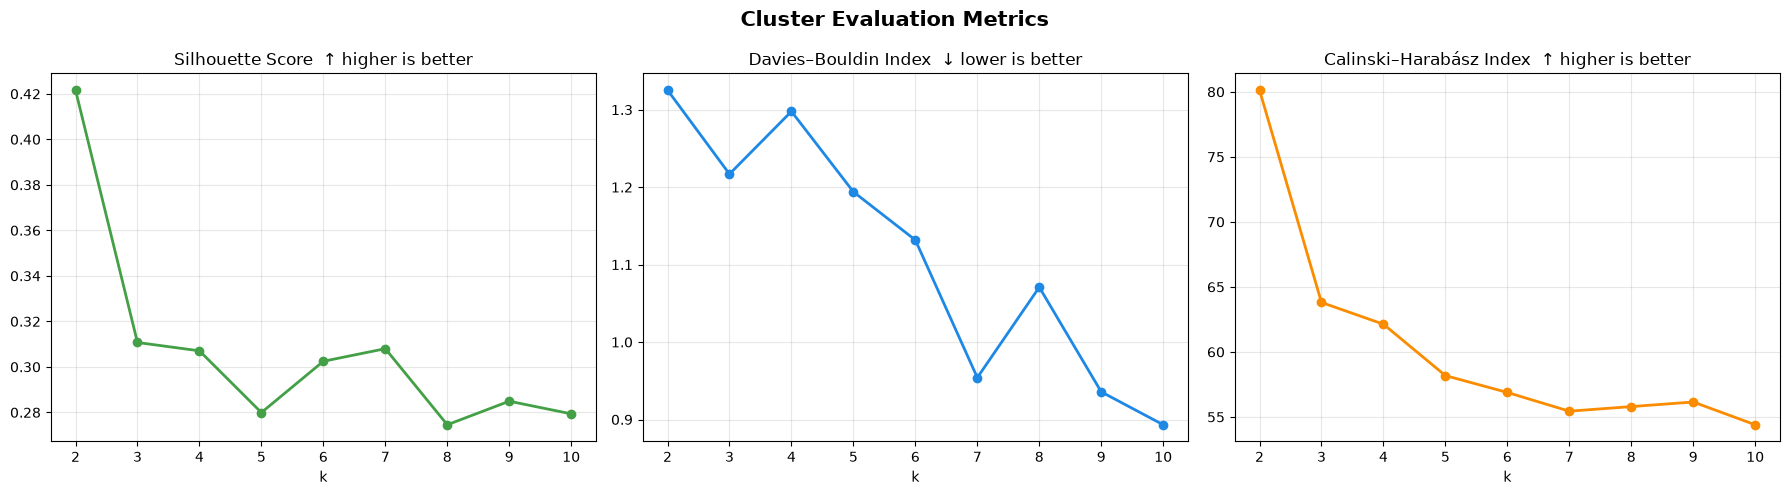

Summary table:
 k  Silhouette  Davies-Bouldin  Calinski-Harabasz
 2      0.4217          1.3253            80.1344
 3      0.3107          1.2169            63.8055
 4      0.3071          1.2978            62.1335
 5      0.2799          1.1940            58.1817
 6      0.3025          1.1317            56.8847
 7      0.3080          0.9541            55.4454
 8      0.2746          1.0708            55.7985
 9      0.2849          0.9357            56.1517
10      0.2794          0.8932            54.4013


In [17]:
silhouette_scores, db_scores, ch_scores = [], [], []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

ks = list(range(2, 11))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Cluster Evaluation Metrics", fontsize=15, fontweight="bold")

axes[0].plot(ks, silhouette_scores, marker="o", color="#43A047", linewidth=2)
axes[0].set_title("Silhouette Score  ↑ higher is better")
axes[0].set_xlabel("k"); axes[0].grid(alpha=0.3)

axes[1].plot(ks, db_scores, marker="o", color="#1E88E5", linewidth=2)
axes[1].set_title("Davies–Bouldin Index  ↓ lower is better")
axes[1].set_xlabel("k"); axes[1].grid(alpha=0.3)

axes[2].plot(ks, ch_scores, marker="o", color="#FB8C00", linewidth=2)
axes[2].set_title("Calinski–Harabász Index  ↑ higher is better")
axes[2].set_xlabel("k"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Summary table:")
summary = pd.DataFrame({"k": ks, "Silhouette": silhouette_scores,
                        "Davies-Bouldin": db_scores, "Calinski-Harabasz": ch_scores})
print(summary.round(4).to_string(index=False))

## 8. Train Final KMeans Model

In [18]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20, max_iter=500)
df["Cluster"] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df["Cluster"])
db  = davies_bouldin_score(X_scaled, df["Cluster"])
ch  = calinski_harabasz_score(X_scaled, df["Cluster"])

print(f"Final Model — k = {N_CLUSTERS}")
print(f"  Silhouette Score     : {sil:.4f}  (closer to 1 is best)")
print(f"  Davies-Bouldin Index : {db:.4f}  (lower is best)")
print(f"  Calinski-Harabasz    : {ch:.2f}  (higher is best)")

print("Cluster sizes:")
print(df["Cluster"].value_counts().sort_index())

Final Model — k = 4
  Silhouette Score     : 0.3071  (closer to 1 is best)
  Davies-Bouldin Index : 1.2978  (lower is best)
  Calinski-Harabasz    : 62.13  (higher is best)
Cluster sizes:
Cluster
0     31
1     26
2     30
3    118
Name: count, dtype: int64


## 9. Cluster Analysis

In [19]:
# Cluster-wise mean nutrients
cluster_means = df.groupby("Cluster")[FEATURES].mean().round(2)
cluster_means.index = [f"Cluster {i} — {CLUSTER_LABELS[i]}" for i in cluster_means.index]
cluster_means

,calories,protein,carbs,fat,iron,vitamin_c
Cluster 0 — High-Calorie Dense Foods,612.10,3.33,44.36,19.16,0.95,9.15
Cluster 1 — Vitamin-Rich Foods,127.65,1.21,18.42,0.29,0.45,51.17
Cluster 2 — High-Protein Dense Foods,431.40,9.56,35.53,10.40,2.76,6.02
Cluster 3 — Balanced Light Foods,124.92,1.39,19.69,2.71,0.42,8.42


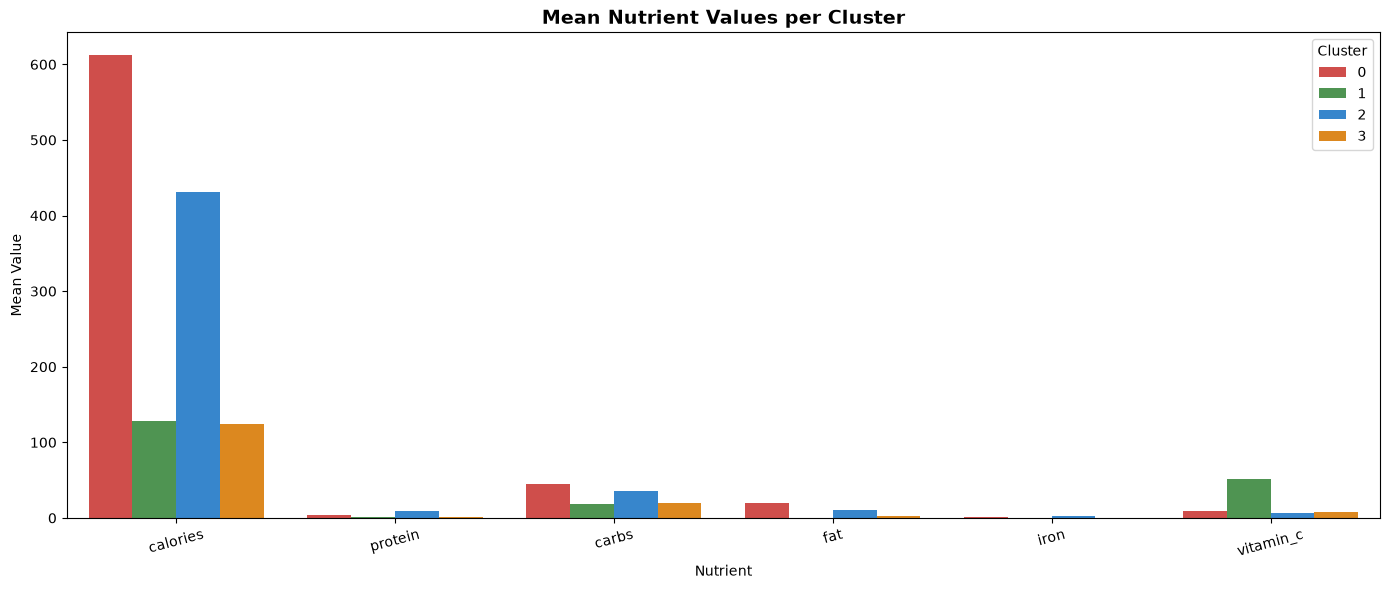

In [20]:
# Bar chart comparison
means = df.groupby("Cluster")[FEATURES].mean().reset_index()
melted = means.melt(id_vars="Cluster", var_name="Nutrient", value_name="Mean Value")

plt.figure(figsize=(14, 6))
sns.barplot(data=melted, x="Nutrient", y="Mean Value",
            hue="Cluster", palette=list(CLUSTER_COLORS.values()))
plt.title("Mean Nutrient Values per Cluster", fontsize=14, fontweight="bold")
plt.xticks(rotation=15)
plt.legend(title="Cluster", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## 10. Visualizations
### 10.1 PCA — 2D Cluster Plot

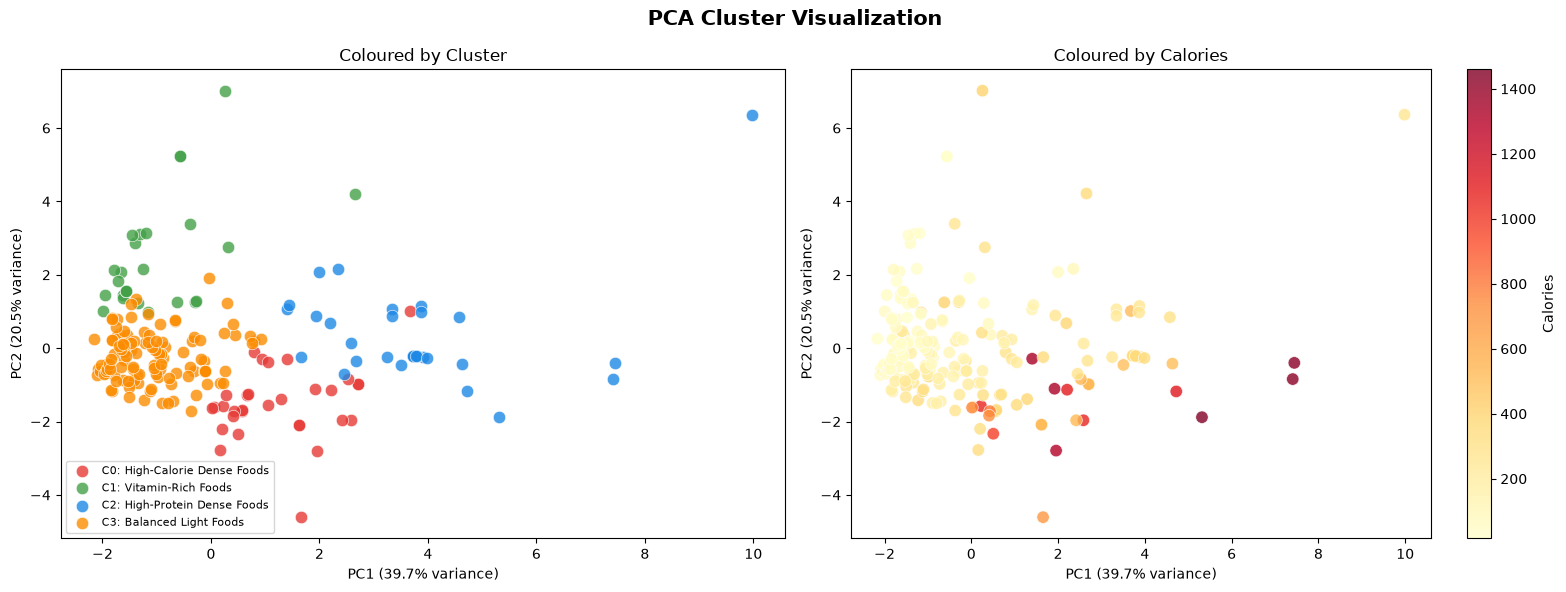

In [21]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA Cluster Visualization", fontsize=15, fontweight="bold")

for c in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == c
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    label=f"C{c}: {CLUSTER_LABELS[c]}",
                    color=CLUSTER_COLORS[c], s=80, alpha=0.8,
                    edgecolors="white", linewidths=0.5)
axes[0].set_title("Coloured by Cluster")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].legend(fontsize=8)

sc = axes[1].scatter(coords[:, 0], coords[:, 1], c=df["calories"],
                     cmap="YlOrRd", s=80, alpha=0.8, edgecolors="white", linewidths=0.5)
plt.colorbar(sc, ax=axes[1], label="Calories")
axes[1].set_title("Coloured by Calories")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

plt.tight_layout()
plt.show()

### 10.2 Radar / Spider Charts — Cluster Nutritional Profiles

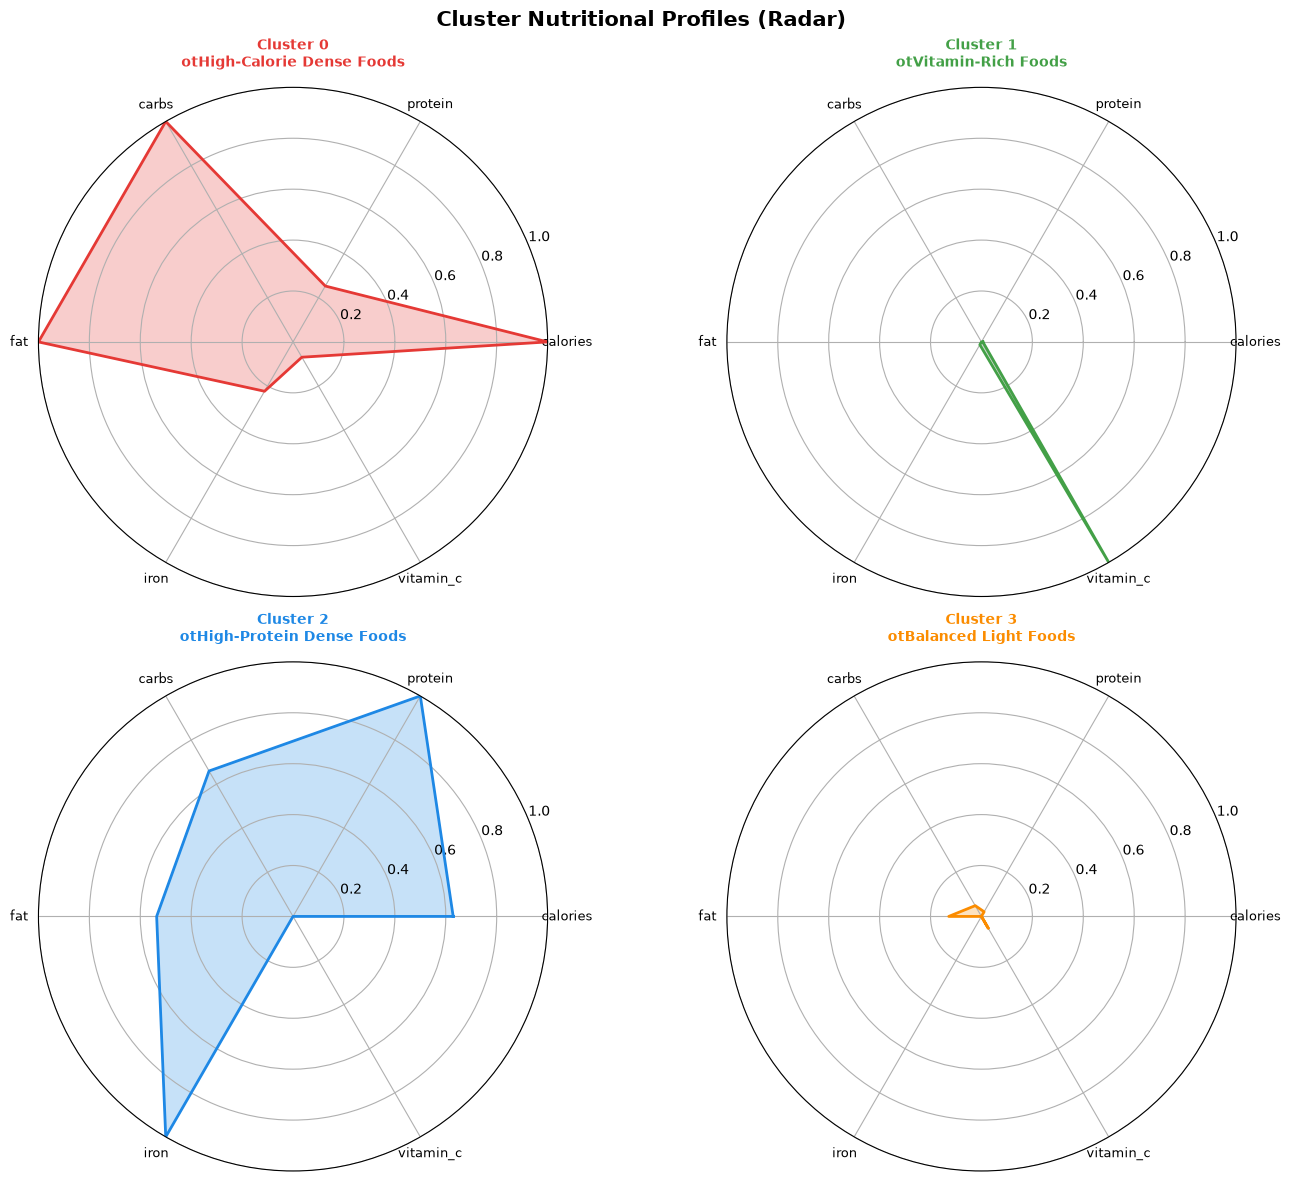

In [23]:
means_norm = df.groupby("Cluster")[FEATURES].mean()
norm = (means_norm - means_norm.min()) / (means_norm.max() - means_norm.min() + 1e-9)

categories = FEATURES
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
fig.suptitle("Cluster Nutritional Profiles (Radar)", fontsize=15, fontweight="bold")

for idx, (cluster_id, ax) in enumerate(zip(sorted(df["Cluster"].unique()), axes.flatten())):
    values = norm.loc[cluster_id].values.tolist() + [norm.loc[cluster_id].values[0]]
    color = CLUSTER_COLORS[cluster_id]
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_title(f"Cluster {cluster_id}\not{CLUSTER_LABELS[cluster_id]}",
                 size=10, fontweight="bold", pad=15, color=color)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 10.3 Nutrient Distributions by Cluster

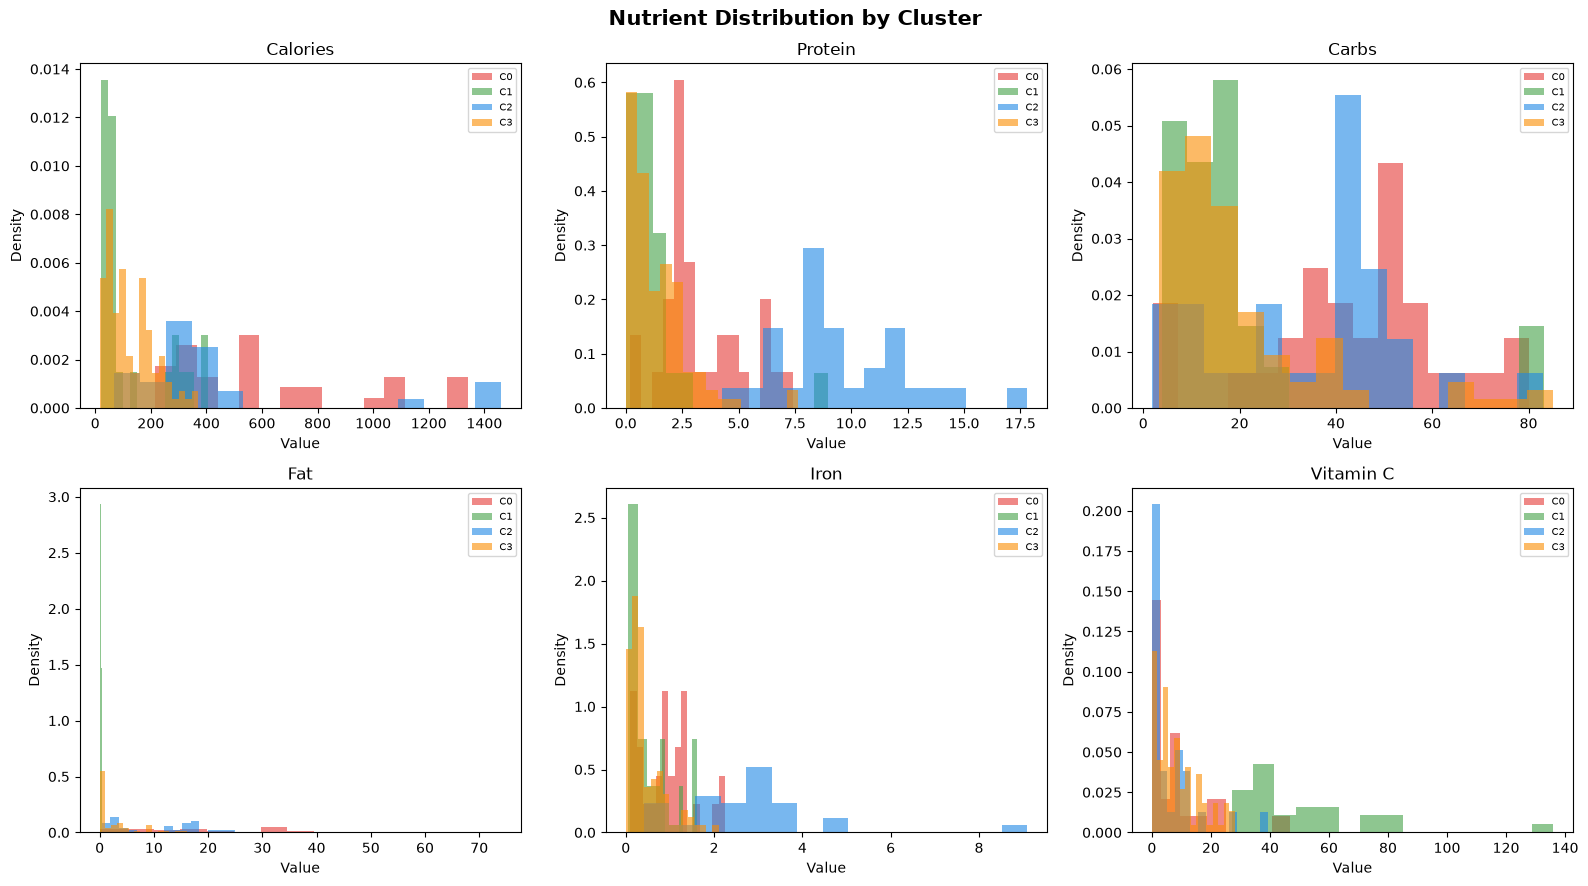

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Nutrient Distribution by Cluster", fontsize=15, fontweight="bold")

for ax, feat in zip(axes.flatten(), FEATURES):
    for c in sorted(df["Cluster"].unique()):
        subset = df[df["Cluster"] == c][feat]
        ax.hist(subset, bins=15, alpha=0.6, color=CLUSTER_COLORS[c],
                label=f"C{c}", density=True)
    ax.set_title(feat.replace("_", " ").title())
    ax.set_xlabel("Value"); ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

### 10.4 Calories vs Protein Scatter (Classic)

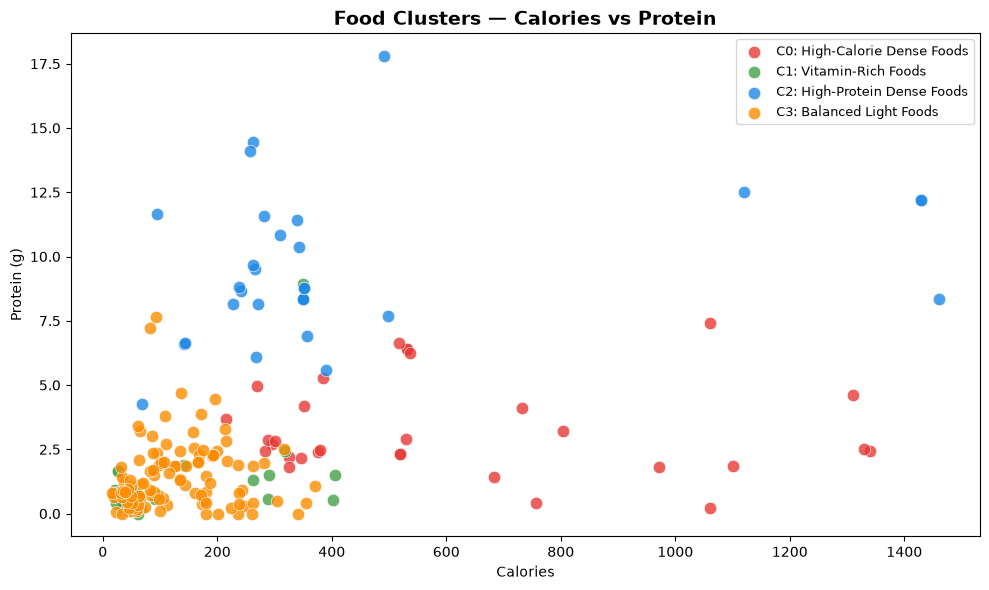

In [25]:
plt.figure(figsize=(10, 6))
for c in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == c
    plt.scatter(df[mask]["calories"], df[mask]["protein"],
                label=f"C{c}: {CLUSTER_LABELS[c]}",
                color=CLUSTER_COLORS[c], s=80, alpha=0.8,
                edgecolors="white", linewidths=0.5)
plt.title("Food Clusters — Calories vs Protein", fontsize=14, fontweight="bold")
plt.xlabel("Calories"); plt.ylabel("Protein (g)")
plt.legend(fontsize=9, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## 11. Recommendation Engine

In [26]:
def get_recommendations(
    df, scaler, model,
    goal="balanced",
    top_n=10,
    max_calories=None,
    min_protein=None,
    exclude_category=None
):
    """
    Recommend foods based on a health goal.

    Parameters
    ----------
    goal : str
        "balanced"    → Cluster 0
        "vitamin_rich" → Cluster 1
        "high_protein" → Cluster 2
        "high_energy"  → Cluster 3
        "weight_loss"  → lowest calorie foods (cross-cluster)
        "muscle_gain"  → highest protein foods (cross-cluster)
    max_calories : float, optional  — filter by max calories
    min_protein  : float, optional  — filter by min protein
    exclude_category : list, optional — categories to exclude
    """
    GOAL_CLUSTER = {"balanced": 0, "vitamin_rich": 1, "high_protein": 2, "high_energy": 3}

    filtered = df.copy()
    if max_calories:  filtered = filtered[filtered["calories"] <= max_calories]
    if min_protein:   filtered = filtered[filtered["protein"]  >= min_protein]
    if exclude_category:
        filtered = filtered[~filtered["category"].isin(exclude_category)]

    # Dynamic cross-cluster goals
    if goal == "weight_loss":
        result = filtered.nsmallest(top_n, "calories")[["food_name","category"]+FEATURES]
        result.insert(0, "Rank", range(1, len(result)+1))
        result.insert(2, "Goal", "Weight Loss")
        return result.reset_index(drop=True)

    if goal == "muscle_gain":
        result = filtered.nlargest(top_n, "protein")[["food_name","category"]+FEATURES]
        result.insert(0, "Rank", range(1, len(result)+1))
        result.insert(2, "Goal", "Muscle Gain")
        return result.reset_index(drop=True)

    if goal not in GOAL_CLUSTER:
        raise ValueError(f"Unknown goal '{goal}'. Choose from: {list(GOAL_CLUSTER)+['weight_loss','muscle_gain']}")

    target_cluster = GOAL_CLUSTER[goal]
    cluster_foods  = filtered[filtered["Cluster"] == target_cluster].copy()

    # Rank by centroid distance — most representative foods first
    centroid = model.cluster_centers_[target_cluster]
    eng = cluster_foods[FEATURES].assign(
        protein_per_cal    = cluster_foods["protein"] / (cluster_foods["calories"]+1),
        carb_per_cal       = cluster_foods["carbs"]   / (cluster_foods["calories"]+1),
        fat_per_cal        = cluster_foods["fat"]     / (cluster_foods["calories"]+1),
        micronutrient_score= cluster_foods["iron"]*2  + cluster_foods["vitamin_c"]*0.1,
    )[ENGINEERED_FEATURES]

    distances = np.linalg.norm(scaler.transform(eng) - centroid, axis=1)
    cluster_foods["distance"] = distances
    result = cluster_foods.nsmallest(top_n, "distance")[["food_name","category"]+FEATURES]
    result.insert(0, "Rank", range(1, len(result)+1))
    result.insert(2, "Goal", CLUSTER_LABELS[target_cluster])
    return result.reset_index(drop=True)

print("Recommendation engine ready ✓")

Recommendation engine ready ✓


### 11.1 Weight Loss Recommendations

In [27]:
get_recommendations(df, scaler, kmeans, goal="weight_loss", top_n=10, max_calories=100)

,Rank,food_name,Goal,category,calories,protein,carbs,fat,iron,vitamin_c
0,1,"Tomatoes, red, ripe, canned, packed in tomato ...",Weight Loss,Vegetables and Vegetable Products,16.0,0.79,3.47,0.25,0.57,12.6
1,2,"Soup, tomato",Weight Loss,"Soups, broth-based",19.0,0.65,3.64,0.41,0.44,5.9
2,3,"Tomatoes, raw",Weight Loss,Tomatoes,20.0,0.82,4.04,0.31,0.22,16.3
3,4,Tomato juice cocktail,Weight Loss,Vegetable juice,22.0,0.93,3.87,0.31,0.28,54.3
4,5,"Grape juice drink, light",Weight Loss,Fruit drinks,23.0,0.06,5.51,0.10,0.03,17.6
5,6,"Strawberry juice, 100%",Weight Loss,Other fruit juice,23.0,0.42,5.17,0.14,0.17,38.7
6,7,"Pepper, banana, raw",Weight Loss,Vegetables and Vegetable Products,27.0,1.66,5.35,0.45,0.46,82.7
7,8,"Peppers, banana, raw",Weight Loss,Other vegetables and combinations,27.0,1.66,5.35,0.45,0.46,82.7
8,9,"Tomatoes, grape, raw",Weight Loss,Vegetables and Vegetable Products,27.0,0.83,5.51,0.63,0.33,27.2
9,10,"Onions, green, raw",Weight Loss,Onions,32.0,1.83,7.34,0.19,1.48,18.8


### 11.2 Muscle Gain Recommendations

In [28]:
get_recommendations(df, scaler, kmeans, goal="muscle_gain", top_n=10, min_protein=5)

,Rank,food_name,Goal,category,calories,protein,carbs,fat,iron,vitamin_c
0,1,"HORMEL ALWAYS TENDER, Pork Loin Filets, Lemon ...",Muscle Gain,Pork Products,492.0,17.80,1.79,4.16,0.60,1.70
1,2,Orange chicken,Muscle Gain,Stir-fry and soy-based sauce mixtures,262.0,14.46,22.46,12.68,0.94,0.90
2,3,Sun-dried tomatoes,Muscle Gain,Tomatoes,258.0,14.11,55.76,2.97,9.09,39.20
3,4,"Bread, potato",Muscle Gain,Baked Products,1120.0,12.50,47.10,3.13,2.25,0.00
4,5,"PIZZA HUT, breadstick, parmesan garlic",Muscle Gain,Fast Foods,1430.0,12.20,44.50,12.90,4.65,7.45
5,6,"Fast foods, breadstick, soft, prepared with ga...",Muscle Gain,Fast Foods,1430.0,12.20,44.50,12.90,4.65,0.00
6,7,Pork with chili and tomatoes,Muscle Gain,Meat mixed dishes,95.0,11.64,2.68,3.99,0.58,16.70
7,8,"Shrimp in garlic sauce, Puerto Rican style",Muscle Gain,Seafood mixed dishes,281.0,11.56,2.45,24.96,0.41,12.00
8,9,"Garlic bread, with melted cheese, from fast fo...",Muscle Gain,Yeast breads,339.0,11.41,34.21,17.34,2.48,0.20
9,10,"Roll, garlic",Muscle Gain,Rolls and buns,309.0,10.84,51.92,6.44,3.71,0.20


### 11.3 Vitamin-Rich Foods

In [29]:
get_recommendations(df, scaler, kmeans, goal="vitamin_rich", top_n=10)

,Rank,food_name,Goal,category,calories,protein,carbs,fat,iron,vitamin_c
0,1,"Orange, raw",Vitamin-Rich Foods,Citrus fruits,50.0,0.92,11.78,0.14,0.22,56.2
1,2,"Oranges, raw, navels",Vitamin-Rich Foods,Fruits and Fruit Juices,47.0,0.91,11.80,0.15,0.33,59.1
2,3,"Strawberries, raw",Vitamin-Rich Foods,Strawberries,36.0,0.64,7.96,0.22,0.26,59.6
3,4,"Oranges, raw, Florida",Vitamin-Rich Foods,Fruits and Fruit Juices,46.0,0.70,11.50,0.21,0.09,45.0
4,5,"Grape juice, 100%",Vitamin-Rich Foods,Other fruit juice,66.0,0.18,15.73,0.28,0.08,50.4
5,6,"Strawberries, frozen",Vitamin-Rich Foods,Strawberries,35.0,0.43,9.13,0.11,0.75,41.2
6,7,"Strawberry juice, 100%",Vitamin-Rich Foods,Other fruit juice,23.0,0.42,5.17,0.14,0.17,38.7
7,8,"Mango, raw",Vitamin-Rich Foods,Mango and papaya,60.0,0.82,14.98,0.38,0.16,36.4
8,9,"Mango, frozen",Vitamin-Rich Foods,Mango and papaya,60.0,0.82,14.98,0.38,0.16,36.4
9,10,"Mangos, raw",Vitamin-Rich Foods,Fruits and Fruit Juices,60.0,0.82,15.00,0.38,0.16,36.4


### 11.4 Balanced Foods (excluding sweets)

In [30]:
get_recommendations(df, scaler, kmeans, goal="balanced", top_n=10,
                    exclude_category=["Sweets", "Cakes and pies"])

,Rank,food_name,Goal,category,calories,protein,carbs,fat,iron,vitamin_c
0,1,Fried onion rings,High-Calorie Dense Foods,Fried vegetables,352.0,4.19,39.94,19.82,0.96,1.50
1,2,"DENNY'S, onion rings",High-Calorie Dense Foods,Restaurant Foods,385.0,5.29,41.00,22.20,0.74,7.45
2,3,Banana chips,High-Calorie Dense Foods,Dried fruits,519.0,2.30,58.40,33.60,1.25,6.30
3,4,"Snacks, banana chips",High-Calorie Dense Foods,Snacks,519.0,2.30,58.40,33.60,1.25,6.30
4,5,"Potato chips, unsalted",High-Calorie Dense Foods,Potato chips,537.0,6.25,59.66,30.30,1.19,22.60
5,6,Sweet potato chips,High-Calorie Dense Foods,"Tortilla, corn, other chips",529.0,2.92,56.54,32.19,2.11,0.00
6,7,"Fast foods, sundae, strawberry",High-Calorie Dense Foods,Fast Foods,732.0,4.09,29.20,5.13,0.21,1.30
7,8,Fried green tomatoes,High-Calorie Dense Foods,Fried vegetables,216.0,3.68,21.78,12.84,1.64,6.20
8,9,"Pie, blueberry, commercially prepared",High-Calorie Dense Foods,Baked Products,971.0,1.80,34.90,10.00,0.30,2.70
9,10,"Potato chips, NFS",High-Calorie Dense Foods,Potato chips,532.0,6.39,53.83,33.98,1.28,21.60


### 11.5 High-Energy Foods

In [31]:
get_recommendations(df, scaler, kmeans, goal="high_energy", top_n=10)

,Rank,food_name,Goal,category,calories,protein,carbs,fat,iron,vitamin_c
0,1,"Sweet potato, casserole or mashed",Balanced Light Foods,Other red and orange vegetables,99.0,1.89,17.22,2.56,0.34,10.4
1,2,"Potato, NFS",Balanced Light Foods,"White potatoes, baked or boiled",126.0,1.87,20.45,4.25,0.34,12.1
2,3,"Potato, boiled, NFS",Balanced Light Foods,"White potatoes, baked or boiled",126.0,1.87,20.45,4.25,0.34,12.1
3,4,"Sweet potato, NFS",Balanced Light Foods,Other red and orange vegetables,115.0,1.58,17.14,4.53,0.40,12.4
4,5,Stewed potatoes,Balanced Light Foods,Mashed potatoes and white potato mixtures,103.0,1.99,16.26,3.39,0.38,15.1
5,6,"Sweet potato, cooked, as ingredient",Balanced Light Foods,Not included in a food category,82.0,1.65,18.05,0.40,0.42,13.1
6,7,Banana pudding,Balanced Light Foods,Pudding,160.0,2.57,28.00,4.26,0.42,3.2
7,8,"Blueberries, raw",Balanced Light Foods,Blueberries and other berries,64.0,0.70,14.57,0.31,0.34,8.1
8,9,Stewed potatoes with tomatoes,Balanced Light Foods,Mashed potatoes and white potato mixtures,87.0,1.71,12.89,3.29,0.36,15.1
9,10,"Bananas, overripe, raw",Balanced Light Foods,Fruits and Fruit Juices,85.0,0.73,20.10,0.22,0.41,9.7


## 12. Predict Cluster for a New Food

In [32]:
def predict_new_food(food_input, scaler, model, df, top_n=5):
    """
    Predict the cluster for a new food item and show similar foods.

    Parameters
    ----------
    food_input : dict  — keys: calories, protein, carbs, fat, iron, vitamin_c

    Example
    -------
    predict_new_food({"calories":120, "protein":8, "carbs":15,
                      "fat":4, "iron":1.2, "vitamin_c":12},
                     scaler, kmeans, df)
    """
    new = pd.DataFrame([food_input])
    new["protein_per_cal"]     = new["protein"]  / (new["calories"]+1)
    new["carb_per_cal"]        = new["carbs"]    / (new["calories"]+1)
    new["fat_per_cal"]         = new["fat"]      / (new["calories"]+1)
    new["micronutrient_score"] = new["iron"]*2   + new["vitamin_c"]*0.1

    new_scaled = scaler.transform(new[ENGINEERED_FEATURES])
    cluster    = model.predict(new_scaled)[0]

    print(f"Predicted Cluster : {cluster} — {CLUSTER_LABELS[cluster]}")
    print(f"Top {top_n} Similar Foods:")
    display(df[df["Cluster"]==cluster][["food_name","category"]+FEATURES].head(top_n).reset_index(drop=True))

print("predict_new_food() ready ✓")

predict_new_food() ready ✓


In [33]:
# Example 1 — moderate protein food
predict_new_food(
    {"calories": 120, "protein": 8, "carbs": 15, "fat": 4, "iron": 1.2, "vitamin_c": 12},
    scaler, kmeans, df, top_n=5
)

Predicted Cluster : 2 — High-Protein Dense Foods
Top 5 Similar Foods:


,food_name,category,calories,protein,carbs,fat,iron,vitamin_c
0,Orange chicken,Stir-fry and soy-based sauce mixtures,262.0,14.46,22.46,12.68,0.94,0.9
1,"Grape leaves, canned",Vegetables and Vegetable Products,69.0,4.27,11.70,1.97,2.98,11.3
2,"Grape leaves, raw",Vegetables and Vegetable Products,390.0,5.60,17.30,2.12,2.63,11.1
3,Stuffed grape leaves with beef and rice,Meat mixed dishes,228.0,8.15,11.30,17.03,1.91,9.7
4,Stuffed grape leaves with lamb and rice,Meat mixed dishes,271.0,8.17,11.89,21.52,1.83,8.0


In [34]:
# Example 2 — low calorie, high vitamin C (e.g. citrus)
predict_new_food(
    {"calories": 50, "protein": 1, "carbs": 12, "fat": 0.2, "iron": 0.3, "vitamin_c": 60},
    scaler, kmeans, df, top_n=5
)

Predicted Cluster : 1 — Vitamin-Rich Foods
Top 5 Similar Foods:


,food_name,category,calories,protein,carbs,fat,iron,vitamin_c
0,"Apple juice, 100%",Apple juice,48.0,0.09,11.34,0.25,0.06,38.6
1,"Pepper, banana, raw",Vegetables and Vegetable Products,27.0,1.66,5.35,0.45,0.46,82.7
2,"Peppers, banana, raw",Other vegetables and combinations,27.0,1.66,5.35,0.45,0.46,82.7
3,"Orange, raw",Citrus fruits,50.0,0.92,11.78,0.14,0.22,56.2
4,"Orange, canned, NFS",Citrus fruits,46.0,0.60,11.82,0.04,0.26,33.3


## 13. Save Clustered Dataset

In [35]:
output_cols = ["food_name","category"] + FEATURES + ["Cluster"]
df[output_cols].to_csv("Food_Nutrition_Clustered_Enhanced.csv", index=False)
print("Saved: Food_Nutrition_Clustered_Enhanced.csv ✓")
df[output_cols].head(10)

Saved: Food_Nutrition_Clustered_Enhanced.csv ✓


,food_name,category,calories,protein,carbs,fat,iron,vitamin_c,Cluster
0,"Apple, candied",Apples,134.0,1.34,29.61,2.15,0.12,3.6,3
1,"Apple, raw",Apples,61.0,0.17,14.80,0.15,0.03,4.6,3
2,"Apple, dried",Dried fruits,243.0,0.93,65.89,0.32,1.40,3.9,3
3,"Crisp, apple",Cakes and pies,215.0,2.81,30.18,9.59,1.00,0.6,3
4,"Apple, baked",Apples,113.0,0.32,22.70,3.08,0.19,3.9,3
5,Apple cider,Apple juice,46.0,0.10,11.30,0.13,0.12,0.9,3
6,"Cobbler, apple",Cakes and pies,217.0,2.05,33.56,8.66,0.98,0.6,3
7,"Croissants, apple",Baked Products,1060.0,7.40,37.10,8.70,1.10,0.5,0
8,"Pie, apple",Cakes and pies,296.0,2.70,37.55,15.28,1.23,0.5,0
9,"Strudel, apple",Cakes and pies,281.0,1.96,37.18,14.08,0.30,0.5,3


## 14. Foods Per Cluster

In [36]:
for c in sorted(df["Cluster"].unique()):
    print("="*60)
    print(f"  Cluster {c} — {CLUSTER_LABELS[c]}  ({(df['Cluster']==c).sum()} foods)")
    print("="*60)
    display(df[df["Cluster"]==c][["food_name","category"]].head(12).reset_index(drop=True))
    print()

  Cluster 0 — High-Calorie Dense Foods  (31 foods)


,food_name,category
0,"Croissants, apple",Baked Products
1,"Pie, apple",Cakes and pies
2,"Cake or cupcake, apple",Cakes and pies
3,Banana chips,Dried fruits
4,"Cake or cupcake, banana",Cakes and pies
5,"Pie, banana cream",Cakes and pies
6,"Snacks, banana chips",Snacks
7,"Mango, dried, sweetened",Fruits and Fruit Juices
8,"Pears, dried, sulfured, uncooked",Fruits and Fruit Juices
9,"Pie, strawberry",Cakes and pies



  Cluster 1 — Vitamin-Rich Foods  (26 foods)


,food_name,category
0,"Apple juice, 100%",Apple juice
1,"Pepper, banana, raw",Vegetables and Vegetable Products
2,"Peppers, banana, raw",Other vegetables and combinations
3,"Orange, raw",Citrus fruits
4,"Orange, canned, NFS",Citrus fruits
5,"Orange peel, raw",Fruits and Fruit Juices
6,"Orange, canned, in syrup",Citrus fruits
7,"Oranges, raw, Florida",Fruits and Fruit Juices
8,"Oranges, raw, navels",Fruits and Fruit Juices
9,"Oranges, raw, with peel",Fruits and Fruit Juices



  Cluster 2 — High-Protein Dense Foods  (30 foods)


,food_name,category
0,Orange chicken,Stir-fry and soy-based sauce mixtures
1,"Grape leaves, canned",Vegetables and Vegetable Products
2,"Grape leaves, raw",Vegetables and Vegetable Products
3,Stuffed grape leaves with beef and rice,Meat mixed dishes
4,Stuffed grape leaves with lamb and rice,Meat mixed dishes
5,"Bread, potato",Baked Products
6,Potato flour,Vegetables and Vegetable Products
7,Potato pancakes,Vegetables and Vegetable Products
8,"Bread, sweet potato",Yeast breads
9,"Bread, sweet potato, toasted",Yeast breads



  Cluster 3 — Balanced Light Foods  (118 foods)


,food_name,category
0,"Apple, candied",Apples
1,"Apple, raw",Apples
2,"Apple, dried",Dried fruits
3,"Crisp, apple",Cakes and pies
4,"Apple, baked",Apples
5,Apple cider,Apple juice
6,"Cobbler, apple",Cakes and pies
7,"Strudel, apple",Cakes and pies
8,Apple pie filling,Apples
9,Apple salad with dressing,Other fruits and fruit salads
